In [1]:
import os
import numpy as np
import pandas as pd

from skrebate import MultiSURF, TURF

from sklearn.model_selection import train_test_split

In [2]:
output_path = './output'
excluded_column = None
instanceID_label = 'InstanceID'
outcome_label = 'Class'
cat_feat_indexes = None
max_instances = 2000

use_turf = False 
turf_pct = 0.2 

stored_rule_iterations = '500,1000,5000,10000,50000' 
stored_model_iterations = '10,50,100'

In [3]:
df = pd.read_csv('/Users/zartfart/Desktop/URBS HEROS/additional testing datasets/hcc_survival.csv', sep=",")
df.head()

try:
    row_id = df[instanceID_label].values 
except:
    row_id = None

In [4]:
try:
    X = df.drop(excluded_column, axis=1) #Remove excluded column from consideration in this notebook
except:
    X = df
    print('Excluded column not available')
try:
    X = X.drop(instanceID_label,axis=1)
except:
    print('Instance ID coulmn not available')

X = X.drop(outcome_label, axis=1)
feature_names = X.columns 

y = df[outcome_label]

try:
    row_id = df[instanceID_label].values #instance id values
except:
    row_id = None

# using the train test split function
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25, shuffle=True)

Excluded column not available


In [5]:
train_df = pd.concat([X_train, y_train], axis =1)

In [6]:
X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

### Generating Expert Knowlege Scores

In [7]:
def balanced_sampling(df,outcome_label, max_instances):
    """ Returns a dataframe with a sampled number of rows from the original (retaining class balance if possible).
        Assumes that outcome values are either 0 or 1. """
    # Split the DataFrame by class
    df_class_0 = df[df[outcome_label] == 0]
    df_class_1 = df[df[outcome_label] == 1]
    # Determine the number of rows to sample per class
    n_class_0 = max_instances // 2
    n_class_1 = max_instances - n_class_0  # Assign remaining rows to Class 1
    # Ensure we don't sample more rows than available
    n_class_0 = min(n_class_0, len(df_class_0))
    n_class_1 = min(n_class_1, len(df_class_1))
    # Sample rows from each class
    sampled_class_0 = df_class_0.sample(n=n_class_0, replace=False)
    sampled_class_1 = df_class_1.sample(n=n_class_1, replace=False)
    # Combine the sampled rows
    sampled_df = pd.concat([sampled_class_0, sampled_class_1]).reset_index(drop=True)
    return sampled_df

In [8]:

# Further data preparation for expert knowldge generation (i.e. balanced subsampling of training instances for faster run times)
fs_train_df = balanced_sampling(train_df, outcome_label, max_instances)
try:
    fs_X = fs_train_df.drop(excluded_column, axis=1) #Remove excluded column from consideration in this notebook
except:
    fs_X = fs_train_df
    print('Excluded column not available')
try:
    fs_X = fs_X.drop(instanceID_label,axis=1)
except:
    print('Instance ID coulmn not available')
fs_X = fs_X.drop(outcome_label, axis=1)
#Finalize separate array-like objects for X and y
fs_X = fs_X.values
fs_y = fs_train_df[outcome_label].values #outcome values

Excluded column not available
Instance ID coulmn not available


In [9]:
#Generated by AI to fix the following error

#ValueError: setting an array element with a sequence. 
#The requested array has an inhomogeneous shape after 1 dimensions.
# The detected shape was (99,) + inhomogeneous part.


# Build feature matrix from the DataFrame
fs_X_df = fs_train_df.drop(columns=[excluded_column, instanceID_label, outcome_label], errors='ignore')

# Convert any object/string columns to numeric or one-hot encode them
obj_cols = fs_X_df.select_dtypes(include=['object', 'string']).columns
if len(obj_cols) > 0:
    fs_X_df = pd.get_dummies(fs_X_df, columns=obj_cols, dummy_na=False)

# Fill missing values
fs_X_df = fs_X_df.fillna(0)

# Convert to a clean numeric array
fs_X = fs_X_df.to_numpy(dtype=float)

# Encode target if needed
fs_y = fs_train_df[outcome_label].astype(str)
fs_y = pd.factorize(fs_y)[0].astype(int)

print(fs_X.shape)
print(fs_y.shape)

(99, 49)
(99,)


In [10]:
#Optional TURF Parameters --------------
num_scores_to_return = int(X.shape[1]/2.0)
# --------------------------------------
score_path_name = None
if use_turf:
    score_path_name = output_path+'/MultiSURF_TuRF_Scores.csv' #No need to change
else:
    score_path_name = output_path+'/MultiSURF_Scores.csv' #No need to change
# Calculate or load feature importance estimates with MultiSURF or MultiSURF+TuRF ------------------------------------
if not os.path.isfile(score_path_name):
    if use_turf: # Run MultiSURF with TuRF wrapper
        print("Generating MultiSURF/TuRF Scores:")
        clf = TURF(MultiSURF(n_jobs=None), pct=turf_pct, num_scores_to_return=num_scores_to_return).fit(fs_X, fs_y)
        ek = clf.feature_importances_
        score_data = pd.DataFrame({'Feature':feature_names,'Score':ek})
        score_data.to_csv(score_path_name,index=False)
    else: #Just run MultiSURF
        print("Generating MultiSURF Scores:")
        clf = MultiSURF(n_jobs=None).fit(fs_X, fs_y)
        ek = clf.feature_importances_
        score_data = pd.DataFrame({'Feature':feature_names,'Score':ek})
        score_data.to_csv(score_path_name,index=False)
else: #load previously trained scores
    print("Loading MultiSURF Scores")
    loaded_data = pd.read_csv(score_path_name)
    ek = loaded_data['Score'].tolist()
print(list(feature_names))
print(ek)

Loading MultiSURF Scores
['Gender', 'Symptoms', 'Alcohol', 'HepatitisBSurfaceAntigen', 'HepatitisBeAntigen', 'HepatitisBCoreAntibody', 'HepatitisCVirusAntibody', 'Cirrhosis', 'EndemicCountries', 'Smoking', 'Diabetes', 'Obesity', 'Hemochromatosis', 'ArterialHypertension', 'ChronicRenalInsufficiency', 'HIV', 'NASH', 'EsophagealVarices', 'Splenomegaly', 'PortalHypertension', 'PortalVeinThrombosis', 'LiverMetastasis', 'RadiologicalHallmark', 'AgeAtDiagnosis', 'GramsAlcoholPerDay', 'PacksCigarettesPerYear', 'PerformanceStatus', 'EncephalopathyDegree', 'AscitesDegree', 'InternationalNormalisedRatio', 'AlphaFetoprotein', 'Hemoglobin', 'MeanCorpuscularVolume', 'Leukocytes', 'Platelets', 'Albumin', 'TotalBilirubin', 'AlanineTransaminase', 'AspartateTransaminase', 'GammaGlutamylTransferase', 'AlkalinePhosphatase', 'TotalProteins', 'Creatinine', 'NumberOfNodules', 'MajorDimensionOfNodule', 'DirectBilirubin', 'Iron', 'OxygenSaturation', 'Ferritin']
[-0.0445146181811975, 0.120856849344956, -0.02260

###  HEROS 


In [11]:
# HEROS Initialization and Training
from src.skheros.heros import HEROS 
heros = HEROS(iterations=10000, pop_size=500, nu=1, model_iterations=100, model_pop_size=100, verbose = True, stored_rule_iterations = stored_rule_iterations, stored_model_iterations = stored_model_iterations, optimization_method="soft_gini_sgd")
heros = heros.fit(X_train, y_train, row_id, cat_feat_indexes=cat_feat_indexes, ek=ek)

Data Manage Summary: ------------------------------------------------
Number of quantitative features: 49
Number of categorical features: 0
Total Features: 49
Total Instances: 99
Feature Types: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Missing Values: 539
Quantiative Feature Range: [[np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(0.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)], [np.float64(0.0), np.float64(1.0)]

In [12]:
try:
    X_test = X_test.drop(instanceID_label, axis=1)
except:
    pass

In [13]:
best_model_index = heros.auto_select_top_model(X_test,y_test,verbose=True)
set_df = heros.get_model_rules(best_model_index)
print(set_df) #Print all rules of the top model

33 non-dominated models on Pareto-front.
----------------------------------------
Model testing accuracies: [np.float64(0.59375), np.float64(0.5625), np.float64(0.5625), np.float64(0.5), np.float64(0.75), np.float64(0.5), np.float64(0.5625), np.float64(0.5625), np.float64(0.5625), np.float64(0.59375), np.float64(0.5), np.float64(0.6875), np.float64(0.6875), np.float64(0.6893382352941176), np.float64(0.6893382352941176), np.float64(0.71875), np.float64(0.71875), np.float64(0.71875), np.float64(0.6286764705882353), np.float64(0.75), np.float64(0.71875), np.float64(0.75), np.float64(0.6911764705882353), np.float64(0.75), np.float64(0.6268382352941176), np.float64(0.6268382352941176), np.float64(0.6580882352941176), np.float64(0.7536764705882353), np.float64(0.7224264705882353), np.float64(0.6599264705882353), np.float64(0.6599264705882353), np.float64(0.6654411764705883), np.float64(0.6654411764705883)]
Model testing coverages: [np.float64(0.9393939393939394), np.float64(0.878787878787878

In [14]:
from sklearn.metrics import classification_report

predictions = heros.predict(X_test,whole_rule_pop=False, target_model=best_model_index)
print("HEROS Top Model Testing Data Performance Report:")
print(classification_report(predictions, y_test, digits=8))

HEROS Top Model Testing Data Performance Report:
              precision    recall  f1-score   support

           0  0.37500000 0.75000000 0.50000000         8
           1  0.88235294 0.60000000 0.71428571        25

    accuracy                      0.63636364        33
   macro avg  0.62867647 0.67500000 0.60714286        33
weighted avg  0.75935829 0.63636364 0.66233766        33



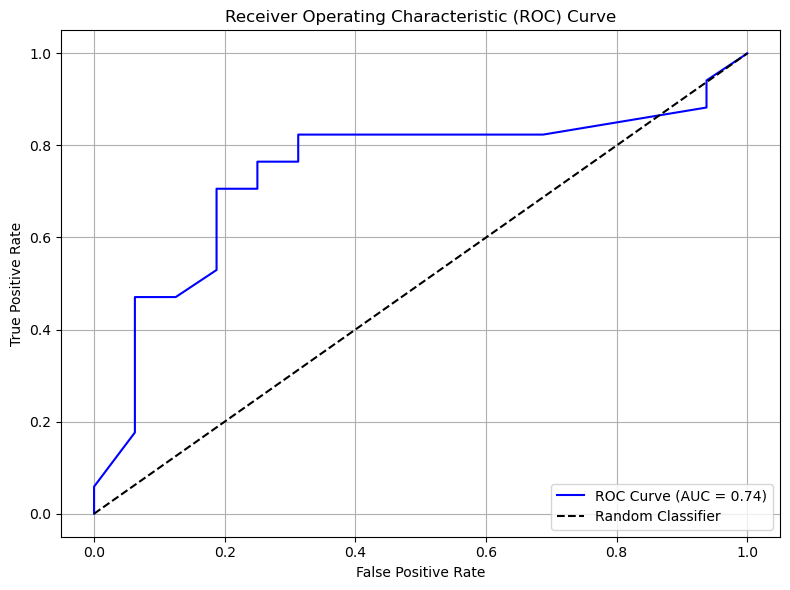

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

predict_prob = heros.predict_proba(X_test,whole_rule_pop=False, target_model=best_model_index)

# Get false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, predict_prob[:, 1]) #based on class 1
# Calculate AUC
roc_auc = roc_auc_score(y_test, predict_prob[:, 1]) #based on class 1
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color='blue')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## Not Working

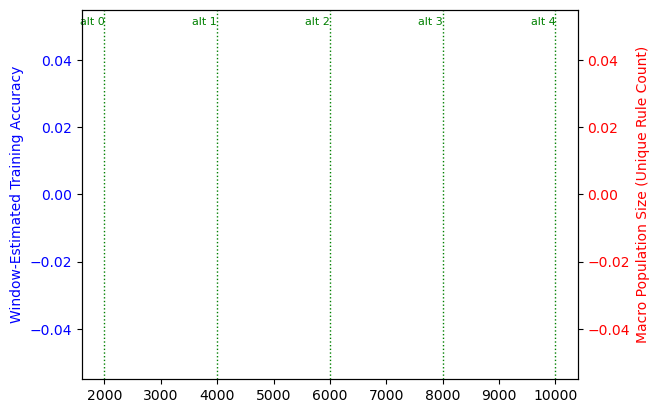

In [16]:
# Save Phase 1 Rule Training Performance Estimates to .csv
rule_tracking_df = heros.get_performance_tracking()
rule_tracking_df.to_csv(output_path+'/rule_pop_tracking.csv', index=False)
# Plot Rule Learning Tracking
heros.get_rule_tracking_plot(show=True,save=True,output_path=output_path)


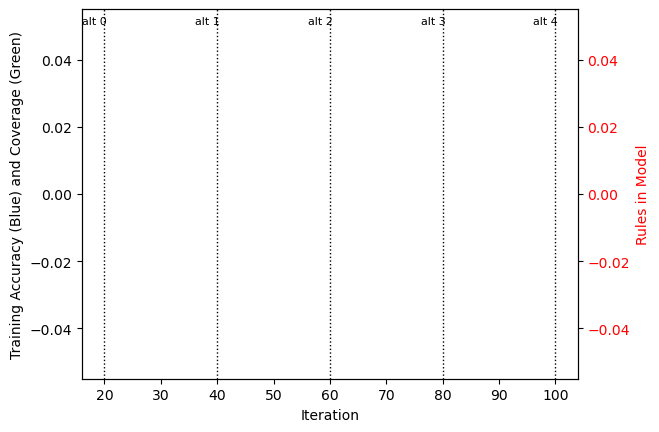

In [17]:
model_tracking_df = heros.get_model_performance_tracking()
model_tracking_df.to_csv(output_path+'/model_tracking.csv', index=False)
# Plot Model Learning Tracking
heros.get_model_tracking_plot(show=True,save=True,output_path=output_path)

IndexError: list index out of range

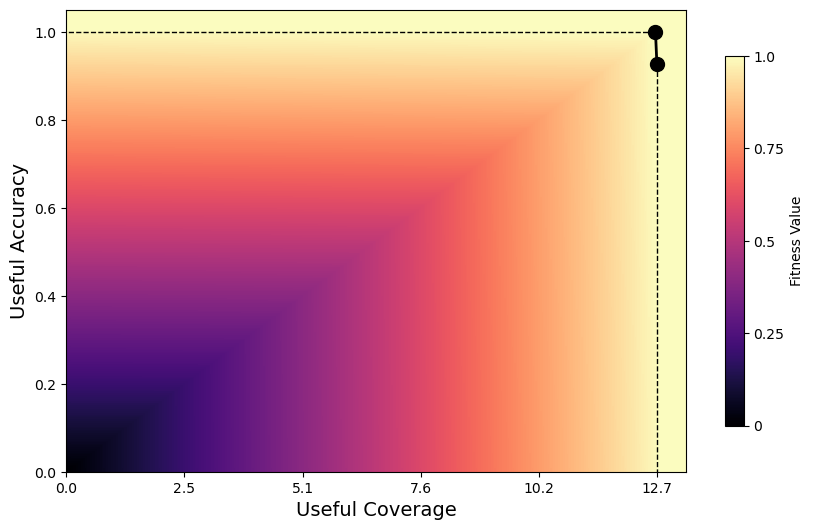

In [18]:
resolution = 500
plot_rules = True
color_rules = True
heros.get_rule_pareto_landscape(resolution, heros.rule_population, plot_rules, color_rules,show=True,save=True,output_path=output_path)